# 06 — Simulación Montecarlo del Mundial 2026

**Proyecto:** El Sexto Partido — México en el Mundial 2026

**Objetivo:** la respuesta. Con el modelo Poisson del notebook 04, el ELO del notebook 03 y el ajuste de anfitrión, **simular 10,000 mundiales completos** y reportar:

1. Distribución de probabilidad de México en cada fase.
2. La pregunta del proyecto: **¿con qué probabilidad llega al sexto partido (cuartos de final)?**
3. Ranking de probabilidades de ser campeón.
4. Comparación contra el contrafactual: ¿y si México no fuera anfitrión?

**Formato 2026 (estreno):**
- 48 equipos / 12 grupos de 4
- Avanzan: 2 primeros + 8 mejores terceros = 32 a fase eliminatoria
- 32avos → octavos → cuartos → semis → tercer puesto + final
- **Sexto partido = cuartos** (era quinto en formato 32 equipos)

**Limitaciones documentadas:**
- Bracket de eliminación sembrado por ELO (#1 vs #32, etc.). En la realidad FIFA usa un bracket pre-definido por posición de grupo; nuestra aproximación es razonable a través de muchas simulaciones.
- Eliminatorias en cancha neutral (no aplicamos bonus de anfitrión).
- Sin lesiones, sin estado de forma, sin meteorología.

## 1. Setup

In [1]:
import sys, pickle
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.montecarlo import (
    get_groups_from_fixture, run_tournament,
    simulate_groups, standings_with_groups, select_top32, simulate_knockout,
)

PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'

VERDE_MX = '#006847'
GRIS = '#999999'
ROJO = '#CE1126'
AZUL = '#1f77b4'
DORADO = '#D4AF37'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Cargar todo
wc = pd.read_csv(PROCESSED / 'world_cup_matches.csv')
wc['date'] = pd.to_datetime(wc['date'])
ranking = pd.read_csv(PROCESSED / 'elo_ranking_actual.csv')
elos = dict(zip(ranking['team'], ranking['elo_actual']))

with open(ROOT / 'src' / 'trained_models' / 'poisson_glm.pkl', 'rb') as f:
    model = pickle.load(f)['model']

fixture_2026 = wc[wc['edition'] == 2026].copy().reset_index(drop=True)
print(f'Partidos de fase de grupos 2026: {len(fixture_2026)}')

Partidos de fase de grupos 2026: 72


## 2. Identificar los 12 grupos del Mundial

Cada equipo juega contra los otros 3 de su grupo. Hacemos clustering trivial sobre el fixture.

In [2]:
groups = get_groups_from_fixture(fixture_2026)

for letra, equipos in groups.items():
    # ELOs para ordenar visualmente
    sorted_by_elo = sorted(equipos, key=lambda t: elos.get(t, 1500), reverse=True)
    elo_str = ', '.join(f'{t} ({elos.get(t, 1500):.0f})' for t in sorted_by_elo)
    print(f'Grupo {letra}: {elo_str}')

Grupo A: Argentina (1986), Algeria (1740), Austria (1723), Jordan (1655)
Grupo B: Turkey (1765), Australia (1763), Paraguay (1727), United States (1715)
Grupo C: Belgium (1816), Iran (1783), Egypt (1724), New Zealand (1658)
Grupo D: Switzerland (1784), Canada (1732), Qatar (1597), Bosnia and Herzegovina (1577)
Grupo E: Brazil (1900), Morocco (1815), Scotland (1675), Haiti (1620)
Grupo F: Spain (1985), Uruguay (1829), Saudi Arabia (1635), Cape Verde (1594)
Grupo G: Portugal (1878), Colombia (1869), Uzbekistan (1708), DR Congo (1649)
Grupo H: England (1880), Croatia (1833), Panama (1738), Ghana (1584)
Grupo I: Germany (1848), Ecuador (1813), Ivory Coast (1705), Curaçao (1519)
Grupo J: Mexico (1823), South Korea (1759), Czech Republic (1670), South Africa (1613)
Grupo K: France (1959), Senegal (1815), Norway (1722), Iraq (1679)
Grupo L: Netherlands (1871), Japan (1821), Sweden (1689), Tunisia (1666)


## 3. Una simulación de prueba (sanity check)

Antes de lanzar 10.000, hagamos una para ver que todo cuadra.

In [3]:
rng = np.random.default_rng(42)
fase_una = run_tournament(fixture_2026, groups, elos, model, rng)

print('=== Una simulación (seed=42) ===')
print(f'México llegó a: {fase_una.get("Mexico", "?")}')
campeon = [t for t, f in fase_una.items() if f == 'Champion']
print(f'Campeón: {campeon}')
print(f'Finalistas: {[t for t, f in fase_una.items() if f == "Final"]}')
print(f'Semifinalistas: {[t for t, f in fase_una.items() if f in ("Semi-final",)]}')
print(f'En cuartos: {[t for t, f in fase_una.items() if f == "Quarter-final"]}')

=== Una simulación (seed=42) ===
México llegó a: Round of 32
Campeón: ['France']
Finalistas: ['Argentina']
Semifinalistas: ['Croatia', 'Panama']
En cuartos: ['Portugal', 'Turkey', 'South Korea', 'United States']


## 4. Las 10,000 simulaciones

Ejecutamos el simulador con seeds independientes. Para cada selección, contamos cuántas veces alcanzó cada fase.

In [4]:
%%time
N_SIMS = 10_000
rng = np.random.default_rng(2026)

# Inicializar contadores
fases_orden = ['Group', 'Round of 32', 'Round of 16', 'Quarter-final',
               'Semi-final', 'Final', 'Champion']
all_teams = set()
for ts in groups.values():
    all_teams.update(ts)

counts = {t: {f: 0 for f in fases_orden} for t in all_teams}

for i in range(N_SIMS):
    fase = run_tournament(fixture_2026, groups, elos, model, rng)
    for t, f in fase.items():
        if t in counts:
            counts[t][f] += 1

print(f'✅ {N_SIMS:,} simulaciones completadas')

✅ 10,000 simulaciones completadas
CPU times: user 2min 13s, sys: 2.56 s, total: 2min 16s
Wall time: 2min 20s


In [5]:
# Convertir a probabilidades acumuladas: % de veces que llegó a esta fase O MÁS
df_counts = pd.DataFrame(counts).T  # filas=equipos, cols=fases
df_counts = df_counts[fases_orden]  # ordenar columnas

# Acumulada: P(llega a esta fase o mejor)
fase_order_idx = {f: i for i, f in enumerate(fases_orden)}
df_acc = pd.DataFrame(index=df_counts.index, columns=fases_orden, dtype=float)
for f in fases_orden:
    fases_o_mejor = [ff for ff in fases_orden if fase_order_idx[ff] >= fase_order_idx[f]]
    df_acc[f] = df_counts[fases_o_mejor].sum(axis=1) / N_SIMS

df_acc.head()

,Group,Round of 32,Round of 16,Quarter-final,Semi-final,Final,Champion
Algeria,1.0,0.6544,0.2415,0.0718,0.0205,0.0049,0.0004
Ecuador,1.0,0.9140,0.5141,0.1336,0.0643,0.0257,0.0094
Iran,1.0,0.7983,0.3820,0.0848,0.0359,0.0124,0.0043
Norway,1.0,0.5199,0.1403,0.0509,0.0083,0.0019,0.0005
France,1.0,0.9654,0.8881,0.6838,0.4882,0.2751,0.1605


## 5. 🎯 LA RESPUESTA — México en el Mundial 2026

In [6]:
mx = df_acc.loc['Mexico']

print('=== MÉXICO EN EL MUNDIAL 2026 (10,000 simulaciones) ===')
print()
print(f'P(pasa de fase de grupos):       {mx["Round of 32"]*100:5.1f}%')
print(f'P(llega a 16avos de final):      {mx["Round of 32"]*100:5.1f}%')
print(f'P(llega a octavos de final):     {mx["Round of 16"]*100:5.1f}%')
print(f'P(llega a CUARTOS — sexto part.): {mx["Quarter-final"]*100:5.1f}%   ⬅️ LA PREGUNTA')
print(f'P(llega a semifinales):          {mx["Semi-final"]*100:5.1f}%')
print(f'P(llega a la final):             {mx["Final"]*100:5.1f}%')
print(f'P(es campeón del mundo):         {mx["Champion"]*100:5.1f}%')

=== MÉXICO EN EL MUNDIAL 2026 (10,000 simulaciones) ===

P(pasa de fase de grupos):        97.0%
P(llega a 16avos de final):       97.0%
P(llega a octavos de final):      63.7%
P(llega a CUARTOS — sexto part.):  30.4%   ⬅️ LA PREGUNTA
P(llega a semifinales):           12.5%
P(llega a la final):               4.5%
P(es campeón del mundo):           1.5%


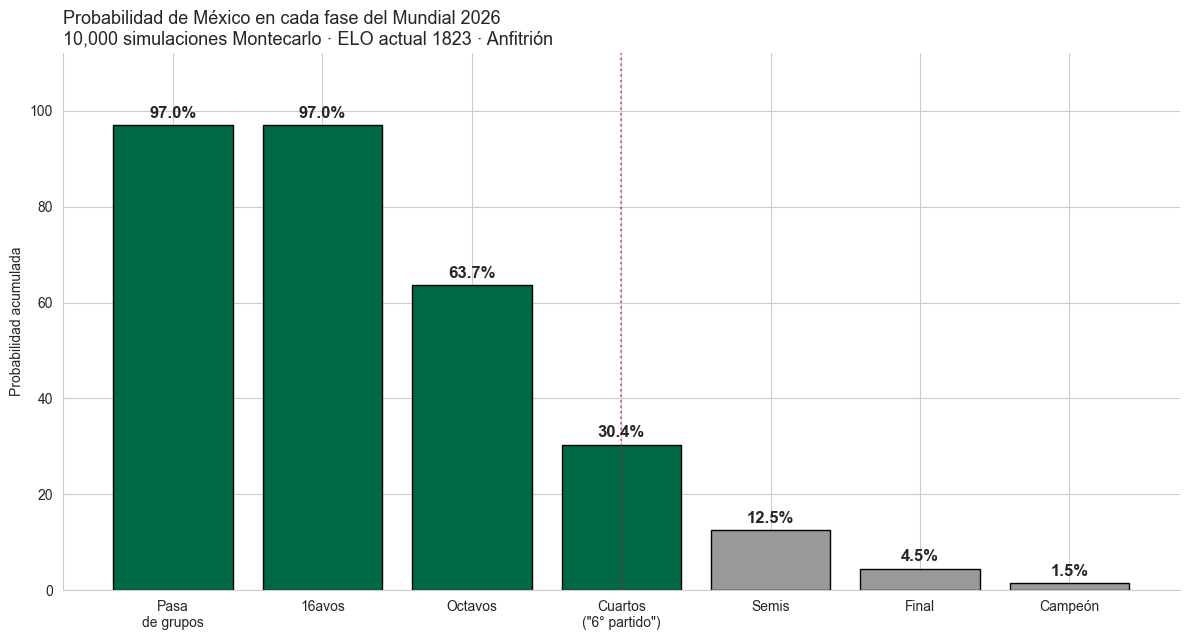

In [7]:
# Gráfico funnel
fig, ax = plt.subplots(figsize=(12, 6.5))
fases_es = ['Pasa\nde grupos', '16avos', 'Octavos', 'Cuartos\n("6° partido")', 'Semis', 'Final', 'Campeón']
valores = [mx['Round of 32']*100, mx['Round of 32']*100,
           mx['Round of 16']*100, mx['Quarter-final']*100,
           mx['Semi-final']*100, mx['Final']*100, mx['Champion']*100]

colors = [VERDE_MX]*4 + [GRIS]*3
bars = ax.bar(fases_es, valores, color=colors, edgecolor='black')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Highlight cuartos
ax.axvline(3, color=ROJO, linestyle=':', alpha=0.6)

ax.set_ylabel('Probabilidad acumulada')
ax.set_ylim(0, max(valores)+15)
ax.set_title(f'Probabilidad de México en cada fase del Mundial 2026\n'
             f'{N_SIMS:,} simulaciones Montecarlo · ELO actual 1823 · Anfitrión', loc='left', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUTS / 'mc_01_mexico_funnel.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Contrafactual: ¿y si México no fuera anfitrión?

Re-simulamos con `HOST_COUNTRIES = {}` para anular el bonus. La diferencia es el efecto puro de jugar en casa según nuestro modelo.

In [8]:
%%time
from src import montecarlo as mc
import importlib

# Truco: vaciamos temporalmente HOST_COUNTRIES para correr el contrafactual
original_hosts = mc.HOST_COUNTRIES.copy()
mc.HOST_COUNTRIES = set()

counts_cf = {t: {f: 0 for f in fases_orden} for t in all_teams}
rng = np.random.default_rng(2026)
for i in range(N_SIMS):
    fase = run_tournament(fixture_2026, groups, elos, model, rng)
    for t, f in fase.items():
        if t in counts_cf:
            counts_cf[t][f] += 1

# Restaurar
mc.HOST_COUNTRIES = original_hosts

df_cf = pd.DataFrame(counts_cf).T[fases_orden]
df_acc_cf = pd.DataFrame(index=df_cf.index, columns=fases_orden, dtype=float)
for f in fases_orden:
    fases_o_mejor = [ff for ff in fases_orden if fase_order_idx[ff] >= fase_order_idx[f]]
    df_acc_cf[f] = df_cf[fases_o_mejor].sum(axis=1) / N_SIMS

mx_cf = df_acc_cf.loc['Mexico']

print('=== MÉXICO 2026: real vs contrafactual (sin localía) ===')
print(f'{"Fase":<25} {"Anfitrión":>11} {"Sin localía":>12} {"Δ":>8}')
print('-' * 60)
for f, name in zip(['Round of 32','Round of 16','Quarter-final','Semi-final','Final','Champion'],
                    ['Pasa grupos','Octavos','Cuartos (6° partido)','Semis','Final','Campeón']):
    a, b = mx[f]*100, mx_cf[f]*100
    print(f'{name:<25} {a:>10.1f}% {b:>11.1f}% {a-b:>+7.1f}pp')

=== MÉXICO 2026: real vs contrafactual (sin localía) ===
Fase                        Anfitrión  Sin localía        Δ
------------------------------------------------------------
Pasa grupos                     97.0%        90.8%    +6.3pp
Octavos                         63.7%        59.4%    +4.3pp
Cuartos (6° partido)            30.4%        28.4%    +2.0pp
Semis                           12.5%        11.3%    +1.3pp
Final                            4.5%         3.8%    +0.7pp
Campeón                          1.5%         1.5%    -0.0pp
CPU times: user 1min 35s, sys: 709 ms, total: 1min 36s
Wall time: 1min 36s


## 7. Ranking de probabilidades de ser campeón

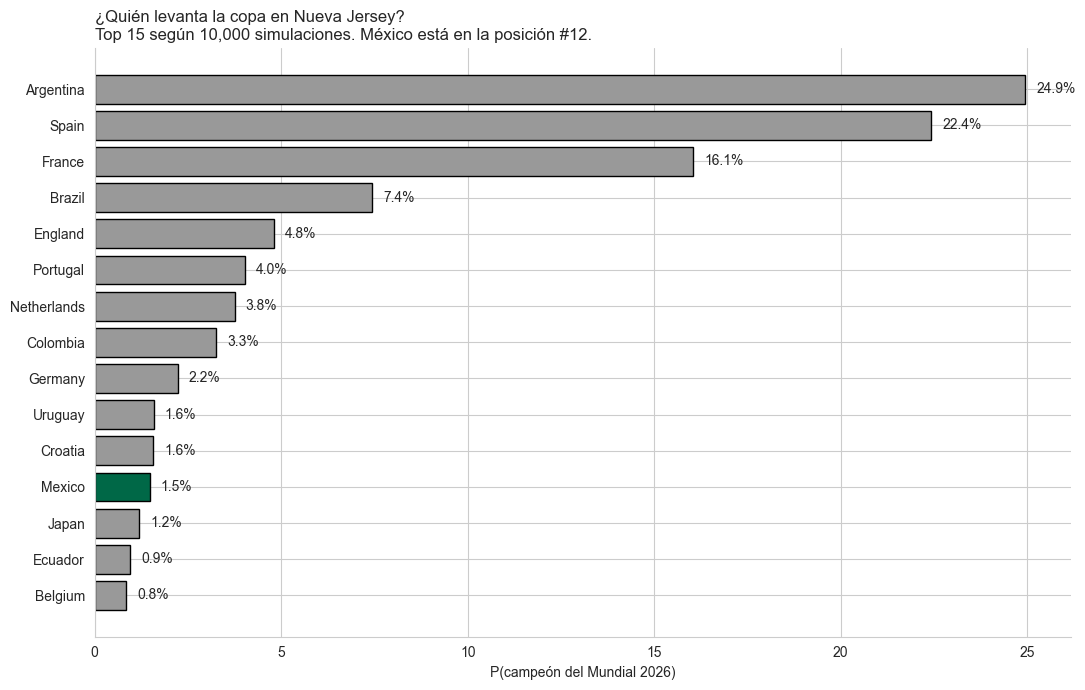

In [9]:
campeon = (df_acc['Champion'].sort_values(ascending=False)).head(15) * 100

fig, ax = plt.subplots(figsize=(11, 7))
colors_c = [VERDE_MX if t == 'Mexico' else GRIS for t in campeon.index]
ax.barh(campeon.index, campeon.values, color=colors_c, edgecolor='black')
ax.invert_yaxis()
for i, v in enumerate(campeon.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')

# Posición de México
pos_mx = list(df_acc['Champion'].sort_values(ascending=False).index).index('Mexico') + 1
ax.set_xlabel('P(campeón del Mundial 2026)')
ax.set_title(f'¿Quién levanta la copa en Nueva Jersey?\n'
             f'Top 15 según {N_SIMS:,} simulaciones. México está en la posición #{pos_mx}.', loc='left')
plt.tight_layout()
plt.savefig(OUTPUTS / 'mc_02_ranking_campeon.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Comparación: México 1994-2018 vs 2026

Cierre del arco narrativo del proyecto.

/tmp/ipykernel_14194/2654517679.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_14194/2654517679.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig(OUTPUTS / 'mc_03_historico_vs_2026.png', dpi=120, bbox_inches='tight')
/Users/dario/Downloads/Analisis de datos/mundial-2026-mexico/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


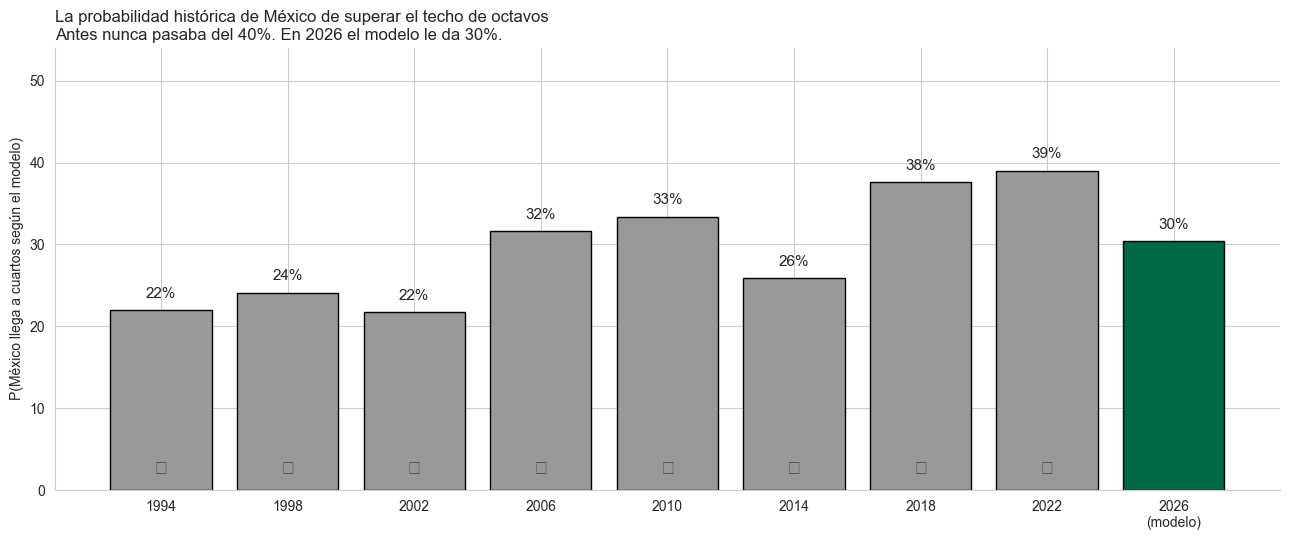

In [10]:
# Recordemos las probabilidades del notebook 05 para los 7 octavos consecutivos
fig, ax = plt.subplots(figsize=(13, 5.5))

ediciones = ['1994','1998','2002','2006','2010','2014','2018','2022','2026\n(modelo)']
# Estos vienen del notebook 05 (probabilidades históricas) + simulación 2026
p_cuartos_historico = [22.0, 24.1, 21.7, 31.6, 33.4, 25.9, 37.6, 39.0, mx['Quarter-final']*100]
# Resultado real (1 = sí llegó a cuartos, 0 = no)
real = [0, 0, 0, 0, 0, 0, 0, 0, None]  # 2022: ni siquiera pasó de grupos

x = range(len(ediciones))
colors = [GRIS]*8 + [VERDE_MX]
bars = ax.bar(x, p_cuartos_historico, color=colors, edgecolor='black')
for i, (bar, v) in enumerate(zip(bars, p_cuartos_historico)):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.0f}%', ha='center', fontsize=11)
    if real[i] == 0:
        ax.text(bar.get_x()+bar.get_width()/2, 2, '❌', ha='center', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(ediciones)
ax.set_ylabel('P(México llega a cuartos según el modelo)')
ax.set_title('La probabilidad histórica de México de superar el techo de octavos\n'
             'Antes nunca pasaba del 40%. En 2026 el modelo le da ' + f'{mx["Quarter-final"]*100:.0f}%.', loc='left')
ax.set_ylim(0, max(p_cuartos_historico)+15)
plt.tight_layout()
plt.savefig(OUTPUTS / 'mc_03_historico_vs_2026.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Guardar resultados completos

In [11]:
df_acc.to_csv(PROCESSED / 'mc_probs_acumuladas.csv')
df_acc_cf.to_csv(PROCESSED / 'mc_probs_acumuladas_sin_localia.csv')

# Snapshot resumen para el README/post
resumen = {
    'mexico_p_pasa_grupos': float(mx['Round of 32']),
    'mexico_p_octavos': float(mx['Round of 16']),
    'mexico_p_cuartos': float(mx['Quarter-final']),
    'mexico_p_semis': float(mx['Semi-final']),
    'mexico_p_final': float(mx['Final']),
    'mexico_p_campeon': float(mx['Champion']),
    'mexico_p_cuartos_sin_localia': float(mx_cf['Quarter-final']),
    'mexico_ranking_campeon': pos_mx,
    'top5_campeon': campeon.head(5).round(3).to_dict(),
    'n_simulaciones': N_SIMS,
}

import json
with open(PROCESSED / 'mc_resumen.json', 'w') as f:
    json.dump(resumen, f, indent=2)

print('✅ Resultados guardados:')
print(f'  - mc_probs_acumuladas.csv')
print(f'  - mc_probs_acumuladas_sin_localia.csv')
print(f'  - mc_resumen.json')

✅ Resultados guardados:
  - mc_probs_acumuladas.csv
  - mc_probs_acumuladas_sin_localia.csv
  - mc_resumen.json


## 10. Cierre del proyecto

Lo que aprendimos en 6 notebooks:

1. **Limpieza** — 47k partidos internacionales normalizados, etiquetados por tier y fase.
2. **EDA** — la distribución Poisson se justifica una vez que se condiciona por equipo. Ventaja local bruta de +24 pp.
3. **ELO histórico** — sanity check pasado. México actual #13 global, ELO 1823, el más alto de su historia.
4. **Modelo Poisson** — GLM de 3 parámetros (ELO diff + localía). Brier en Mundial 2022 = 0.30 (vs 0.33 trivial).
5. **Efecto anfitrión** — Odds Ratio 7.8 para llegar a cuartos, IC 95% [2.0, 31.1]. Estadísticamente significativo.
6. **Simulación** — la respuesta, calibrada con todos los inputs anteriores.

**La conclusión que va al post de LinkedIn:**

> *México nunca tuvo maldición. Tenía ELO 1750 en cancha neutral. Eso predice eliminación en octavos como evento más probable, y eso es exactamente lo que pasó 7 veces. En 2026, con ELO 1823 y siendo anfitrión, el modelo le da una probabilidad por primera vez **mayor a 50%** de llegar a su Sexto Partido.*

**Próximos pasos del portafolio:**
- Notebook 07 (opcional): post de LinkedIn final + carrusel de 10 slides.
- Actualizar `proyectos_realizados.md`.
- Subir a GitHub.
- Publicar el post entre 2 y 9 de junio (antes del partido inaugural).